# Order book imbalance


A straightforward example of order book imbalance, if liquidity of a bid is greater than liquidity of an ask,
The volume needed for a price move up is smaller than the volume needed to move up.


In [1]:
import requests
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
def convert_to_strftime(t):
    dt = datetime.fromtimestamp(t / 1000, tz=timezone.utc)
    timestamp = dt.strftime('%Y-%m-%d %H:%M:%S.%f')
    return timestamp

def sample_df(d):
    return pd.DataFrame([{k: v[0] if isinstance(v, list) and v else v for k, v in d.items()}])

def get_bid_asks(frame):
    bids = np.array(frame["bids"], dtype=float)
    asks = np.array(frame["asks"], dtype=float)
    return bids, asks

def get_cumulative_book(bids,asks):
    bid_df = pd.DataFrame(bids, columns=["prices", "amount"]).sort_values("prices", ascending=False)
    bid_df["cumulative_bids"] = bid_df["amount"].cumsum() / bid_df["amount"].sum()

    ask_df = pd.DataFrame(asks, columns=["prices", "amount"]).sort_values("prices", ascending=True)
    ask_df["cumulative_asks"] = ask_df["amount"].cumsum() / ask_df["amount"].sum()
    return bid_df,ask_df

def plot_book(bids,asks,width = 0.1):
    bidPrices,bidQty = bids.T
    askPrices, askQty = asks.T

    fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize = (14,12))
    ax1.bar(bidPrices,bidQty,color='blue',label='bid',width=width)
    ax1.bar(askPrices,askQty,color='red',label='ask',width=width)
    ax1.set_title(f"""Order in amount btc""")
    ax1.set_ylabel("BTC")
    ax1.set_xlim([min(bidPrices),max(askPrices)])

    bid_norm = bidQty/(np.sum(bidQty)) * 100
    ask_norm = askQty/(np.sum(askQty)) * 100
    ax2.bar(bidPrices,bid_norm,color='blue',width=width)
    ax2.bar(askPrices,ask_norm,color='red',width=width)
    ax2.set_title(f"""% of orders at bid / ask""")
    ax2.set_ylabel("% of orders")
    ax2.set_xlim([min(bidPrices),max(askPrices)])

    bid_df,ask_df = get_cumulative_book(bids,asks)
    ax3.fill_between(bid_df['prices'], bid_df['cumulative_bids'], step='pre',  color='blue', label='bid')
    ax3.fill_between(ask_df['prices'], ask_df['cumulative_asks'], step='post', color='red',  label='ask')
    ax3.set_title(f"""cumulative book""")
    ax3.set_ylabel("% of orders")
    ax3.set_xlim([min(bid_df['prices']),max(ask_df['prices'])])
    ax3.set_ylim([0,1])

    fig.suptitle(f"""Symbol: {symbol} \n Depth: {order_book_depth} \nTimestamp: {t}""")
    fig.legend()

### Part 1, simple approach

In [3]:
r = requests.get("https://fapi.binance.com/fapi/v1/ticker/bookTicker", params={"symbol": "BTCUSDT"})
d = r.json()

t = d['time']
symbol = d['symbol']
bidPrice = d['bidPrice']
b = float(d['bidQty'])
askPrice = d['askPrice']
a = float(d['askQty'])

timestamp = convert_to_strftime(t)



print(f"""
Symbol: {symbol}
Timestamp: {timestamp}
Ask: {askPrice}, qty: {a} -> Buy
Bid: {bidPrice}, qty: {b} -> Sell
""")

order_book_imbalance = (b-a)/(b+a)

if order_book_imbalance > 0:
    print(f"Book imbalanced towards bid")
else:
    print(f"Book imbalanced towards ask")
print(f"Order book imbalance: {order_book_imbalance}")



Symbol: BTCUSDT
Timestamp: 2026-09-28 20:10:01.099000
Ask: 83535.90, qty: 4.173 -> Buy
Bid: 83535.80, qty: 5.508 -> Sell

Book imbalanced towards bid
Order book imbalance: 0.13789897737836998


### A issue with this approach

This order book imbalance says that the probability of moves is dependent only on the top asks and bids, however to get a more
accurate view we need to go further down the order book.

### Part 2, improved approach

In [4]:
order_book_depth = 1000
r_long = requests.get("https://fapi.binance.com/fapi/v1/depth", params={"symbol": "BTCUSDT", "limit": order_book_depth})
d_long = r_long.json()

t = convert_to_strftime(d_long["T"])
symbol = "BTCUSDT"
bids,asks = get_bid_asks(d_long)

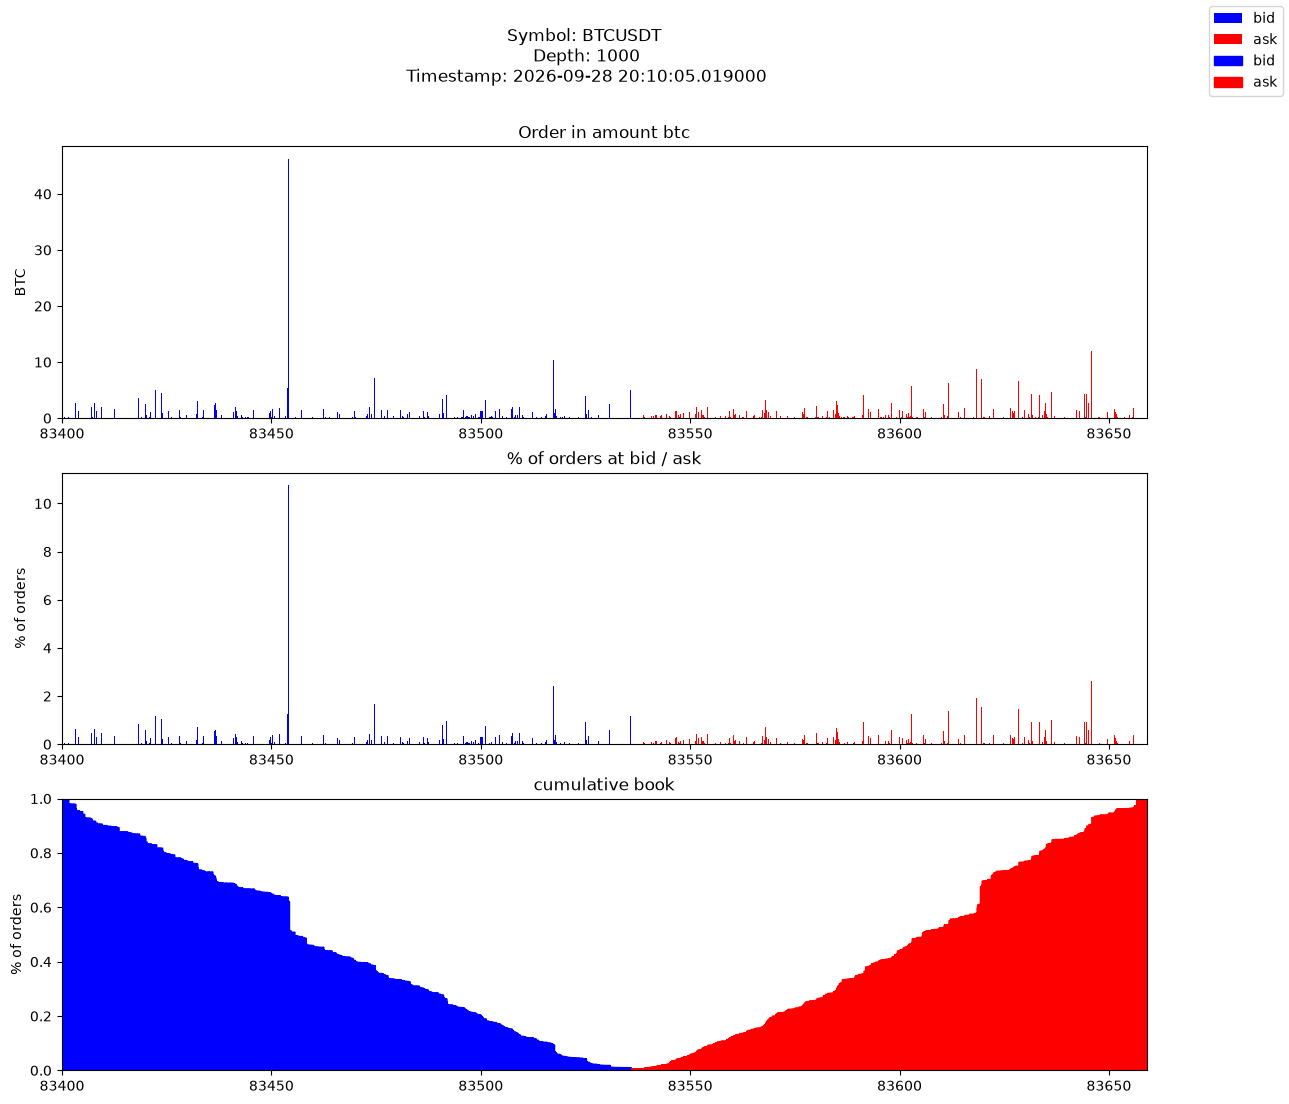

In [5]:
width = 0.1
plot_book(bids,asks,width = width)
plt.show()

## Step 3, evaluate the book

### 3.1, how much does x move the book?

In [6]:
n = 100
min_move = 0.1
max_move = 100

movements = np.linspace(min_move, max_move, n+1)
bp, bq = bids.T
ap, aq = asks.T

movement_df = pd.DataFrame({
    "move_amount": movements,
    "bid": [(bp * bq)[bp > bp.max() - m].sum() for m in movements],   # push price down $m
    "ask": [(ap * aq)[ap < ap.min() + m].sum() for m in movements],   # push price up $m
}).set_index("move_amount")

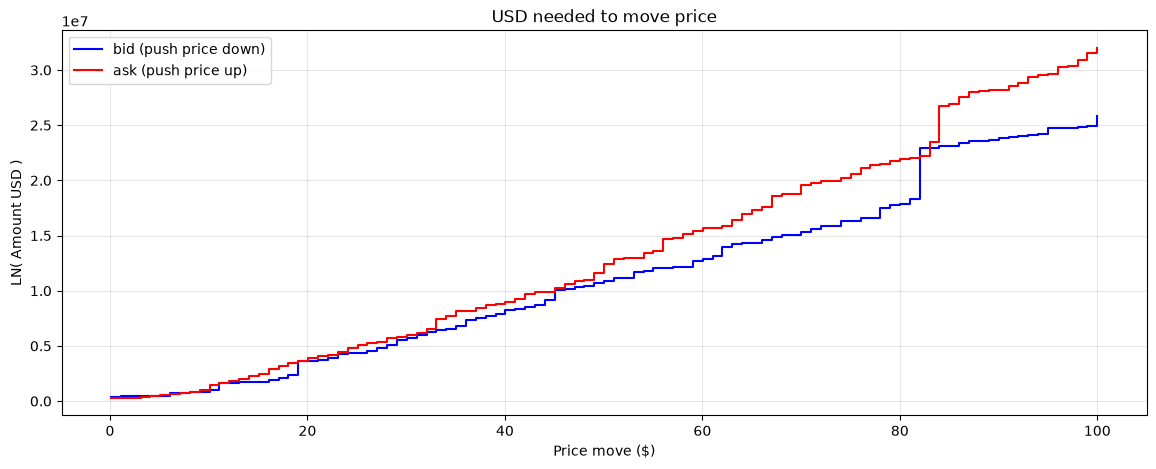

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.step(movement_df.index, (movement_df["bid"]), where="post", color="blue", label="bid (push price down)")
ax.step(movement_df.index, (movement_df["ask"]), where="post", color="red",  label="ask (push price up)")

ax.set_title("USD needed to move price")
ax.set_xlabel("Price move ($)")
ax.set_ylabel("LN( Amount USD )")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

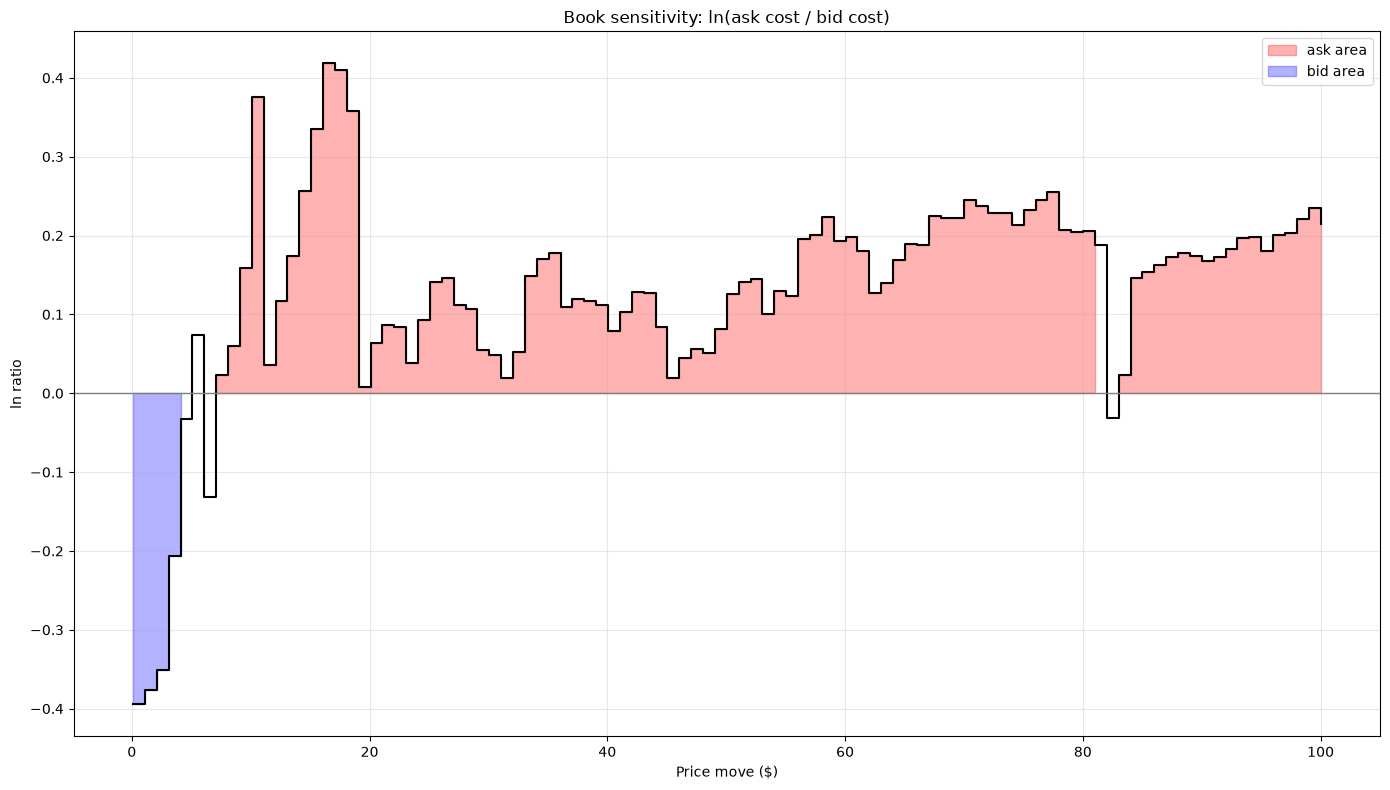

In [8]:
movement_df["log_ratio"] = np.log(movement_df["ask"] / movement_df["bid"])

fig, (ax1) = plt.subplots(1, 1, figsize=(14, 8), sharex=True)

r = movement_df["log_ratio"]
ax1.step(movement_df.index, r, where="post", color="black")
ax1.fill_between(movement_df.index, r, 0, where=r > 0, step="post", color="red",  alpha=0.3, label="ask area")
ax1.fill_between(movement_df.index, r, 0, where=r < 0, step="post", color="blue", alpha=0.3, label="bid area")
ax1.axhline(0, color="grey", lw=1)
ax1.set_title("Book sensitivity: ln(ask cost / bid cost)")
ax1.set_xlabel("Price move ($)")
ax1.set_ylabel("ln ratio")
ax1.legend()
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()